Elapsed time: 0.034000396728515625


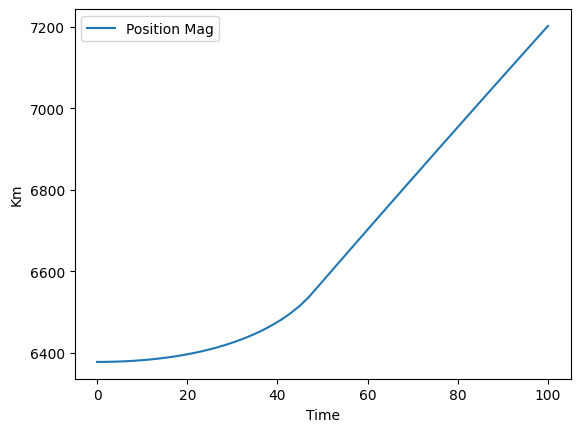

In [28]:
import torch
import torchdiffeq as diffeq
import orbitengine.engine as oe
# Plot the results (requires matplotlib)
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from poliastro.bodies import Earth
from astropy import units as u
import numpy as np



#on ground
r0 = np.array([oe.EARTH_RADIUS_KM.value, 0, 0])*u.km
v0 = np.array([0, oe.EARTH_RADIUS_KM.value*2*np.pi/(24*3600) , 0])*u.km/u.s

k = Earth.k.to(u.km**3/u.s**2)
m0 = 100000*u.kg # rocket + fuel
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
flow = oe.FALCON9_REACTION_MASS_FLOW_RATE

u0 = torch.tensor([*r0.value, *v0.value, m0.value, T0.value])  # Initial state
y0 = [*r0.value, *v0.value, m0.value, T0.value]  # Initial state

t_span = torch.linspace(0.01, 100., 50)

acc_params = oe.AccParams()
acc_params.thrust_vec = torch.tensor([1., 0., 0.])
k = Earth.k.to(u.km**3/u.s**2).value

# Solve the using trochdifeq
#solution = diffeq.odeint(lotka_volterra, u0, t_span, args=()method='dopri5')
import time
ts_start = time.time()
use_torchdiffeq = False
if use_torchdiffeq:
    solution = diffeq.odeint(lambda y,t: oe.twobody(y, t, k, acc_params), u0, t_span, method='dopri5')
    position = solution[:, :3]
    r = torch.norm(position, dim=1)

else:
    # Using odeint
    solution = odeint(oe.twobody_ode, u0, t_span, args=(k, acc_params))
    position = solution[:, :3]
    r = np.linalg.norm(position, axis=1)
ts_stop = time.time()

print(f'Elapsed time: {ts_stop-ts_start}')

plt.plot(t_span, r, label='Position Mag')
plt.xlabel('Time')
plt.ylabel('Km')
plt.legend()
plt.show()



In [186]:

solution = odeint(twobody_ode, u0, t_span, args=(k, acc_params))
position = solution[-1, :3]
print(position)

# Using odeint
t= 100
solution = odeint(twobody_ode, u0, [t], args=(k, acc_params))
position = solution[-1, :3]
print(position)

[25547.35600346   836.54315675     0.        ]
[25547.35600346   836.54315675     0.        ]
